# Process Mining from MIMIC-IV OMOP CDM Event Logs
### ELG × AI × Healthcare — BPM 2026

This notebook loads the five XES event logs generated from the MIMIC-IV OMOP CDM
888-patient sample by `scripts/generate_event_logs.py` and applies process
discovery algorithms to produce process models for each clinical task:

| Task | Process | Key activities |
|------|---------|----------------|
| **T1** | ICU Patient Pathway | Hospital Admission → ICU Admission → ICU Procedure → Discharge |
| **T2** | Medication Administration | Drug Started → Drug Ended (per drug) |
| **T3** | Sepsis Treatment Trajectory | Sepsis Diagnosed → Lab Result → Drug Started → Observation |
| **T4** | Lab-Order-to-Result Cycle | Specimen Collected → Lab Result / Abnormal Result |
| **T5** | Emergency Department Flow | ED Arrival → Sub-Stay → Diagnosis → Procedure → Departure |

**Mining algorithms used:**
- *Directly-Follows Graph (DFG)* — frequency-annotated control-flow overview for all tasks
- *Inductive Miner* — sound, block-structured Petri net for T1 and T5 (manageable activity sets)

**Activity abstraction:** T2, T3, and T4 label activities with OMOP concept names
(e.g., `'Drug Started: Aspirin 81 MG'`).  For readable process models the notebook
collapses these to category-level labels (e.g., `'Drug Started'`) before mining.

Figures are saved to `experiment/figures/` as PNG files suitable for direct
inclusion in the BPM 2026 paper (§5 Demonstration).

---
*Run `scripts/generate_event_logs.py` before executing this notebook.*

In [43]:
# ── Imports ────────────────────────────────────────────────────────────────
import os
import sys
import subprocess
import warnings
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import pm4py
from pm4py.visualization.dfg         import visualizer as dfg_vis
from pm4py.visualization.petri_net   import visualizer as pn_vis
from pm4py.visualization.process_tree import visualizer as pt_vis

from IPython.display import Image, display, Markdown

warnings.filterwarnings('ignore')
print(f'PM4PY version: {pm4py.__version__}')

PM4PY version: 2.7.19.8


In [44]:
# ── Paths ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))   # experiment/
LOGS_DIR      = os.path.join(NOTEBOOK_DIR, 'event_logs')
FIGURES_DIR   = os.path.join(NOTEBOOK_DIR, 'figures')
SCRIPTS_DIR   = os.path.join(NOTEBOOK_DIR, 'scripts')

os.makedirs(LOGS_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# XES file map
XES_FILES = {
    't1': os.path.join(LOGS_DIR, 't1_icu_pathway.xes'),
    't2': os.path.join(LOGS_DIR, 't2_medication_admin.xes'),
    't3': os.path.join(LOGS_DIR, 't3_sepsis_trajectory.xes'),
    't4': os.path.join(LOGS_DIR, 't4_lab_cycle.xes'),
    't5': os.path.join(LOGS_DIR, 't5_ed_flow.xes'),
}

TASK_LABELS = {
    't1': 'T1 — ICU Patient Pathway',
    't2': 'T2 — Medication Administration',
    't3': 'T3 — Sepsis Treatment Trajectory',
    't4': 'T4 — Lab-Order-to-Result Cycle',
    't5': 'T5 — Emergency Department Flow',
}

print('Paths configured:')
for k, v in XES_FILES.items():
    exists = '✓' if os.path.exists(v) else '✗ MISSING'
    print(f'  {k}: {os.path.basename(v)}  [{exists}]')

Paths configured:
  t1: t1_icu_pathway.xes  [✓]
  t2: t2_medication_admin.xes  [✓]
  t3: t3_sepsis_trajectory.xes  [✓]
  t4: t4_lab_cycle.xes  [✓]
  t5: t5_ed_flow.xes  [✓]


## 0 · Generate Event Logs
Run `generate_event_logs.py` if any XES files are missing.

In [45]:
missing = [tid for tid, p in XES_FILES.items() if not os.path.exists(p)]

if missing:
    print(f'Missing XES files for: {missing}  — running generate_event_logs.py …')
    script = os.path.join(SCRIPTS_DIR, 'generate_event_logs.py')
    result = subprocess.run(
        [sys.executable, script, '--tasks'] + missing,
        capture_output=False,
        text=True,
    )
    if result.returncode != 0:
        print('ERROR: generation failed.  Check sample_data/ directory.')
    else:
        print('Event logs generated successfully.')
else:
    print('All XES files present — skipping generation.')

All XES files present — skipping generation.


## 1 · Load Event Logs & Summary Statistics

In [46]:
LOGS = {}
for tid, path in XES_FILES.items():
    if os.path.exists(path):
        print(f'Loading {os.path.basename(path)} …', end=' ')
        # return_legacy_log_object=True: PM4PY ≥2.7 returns a DataFrame by
        # default; we need the EventLog object for trace-level iteration.
        LOGS[tid] = pm4py.read_xes(path, return_legacy_log_object=True)
        print(f'done  ({len(LOGS[tid])} traces)')
    else:
        print(f'[SKIP] {path} not found — run generate_event_logs.py first')

print(f'\nLoaded {len(LOGS)}/5 event logs.')

Loading t1_icu_pathway.xes … 

parsing log, completed traces :: 100%|██████████| 1024/1024 [00:00<00:00, 1744.00it/s]


done  (1024 traces)
Loading t2_medication_admin.xes … 

parsing log, completed traces :: 100%|██████████| 3528/3528 [00:03<00:00, 1071.71it/s]


done  (3528 traces)
Loading t3_sepsis_trajectory.xes … 

...

done  (500 traces)
Loading t4_lab_cycle.xes … 

parsing log, completed traces :: 100%|██████████| 500/500 [00:02<00:00, 208.55it/s]


done  (500 traces)
Loading t5_ed_flow.xes … 

parsing log, completed traces :: 100%|██████████| 526/526 [00:00<00:00, 654.49it/s] 

done  (526 traces)

Loaded 5/5 event logs.


In [47]:
# ── Summary statistics table ────────────────────────────────────────────────
rows = []
for tid, el in LOGS.items():
    n_cases      = len(el)
    n_events     = sum(len(trace) for trace in el)
    act_counts   = Counter(ev['concept:name'] for trace in el for ev in trace)
    n_activities = len(act_counts)
    avg_trace    = n_events / n_cases if n_cases else 0
    rows.append(dict(
        Task       = tid.upper(),
        Name       = TASK_LABELS[tid].split(' — ')[1],
        Cases      = n_cases,
        Events     = n_events,
        Activities = n_activities,
        Avg_Events_per_Case = round(avg_trace, 1),
    ))

summary_df = pd.DataFrame(rows)
display(summary_df.style
        .format({'Events': '{:,}', 'Cases': '{:,}'})
        .set_caption('Table 1 — Event Log Statistics (MIMIC-IV OMOP CDM, 888-patient sample)')
        .hide(axis='index'))

Task,Name,Cases,Events,Activities,Avg_Events_per_Case
T1,ICU Patient Pathway,"1,024","63,594",295,62.100000
T2,Medication Administration,"3,528","399,846",3918,113.300000
T3,Sepsis Treatment Trajectory,500,"1,316,115",2365,2632.200000
T4,Lab-Order-to-Result Cycle,500,"295,735",758,591.500000
T5,Emergency Department Flow,526,"77,320",1839,147.000000


## 2 · Helper Functions

In [48]:
# ── Activity abstraction ────────────────────────────────────────────────────
def abstract_activity(act: str) -> str:
    """
    Collapse concept-level activity labels to category-level labels.

    Examples
    --------
    'Drug Started: Aspirin 81 MG'        → 'Drug Started'
    'Lab Result: Creatinine [ABNORMAL]'  → 'Lab Result [ABNORMAL]'
    'Lab Result: Creatinine'             → 'Lab Result'
    'Specimen Collected: Venous Blood'   → 'Specimen Collected'
    'Hospital Admission'                 → 'Hospital Admission'  (unchanged)
    """
    if ': ' not in act:
        return act
    prefix = act.split(': ')[0]
    if '[ABNORMAL]' in act:
        return prefix + ' [ABNORMAL]'
    return prefix


def abstract_log(el: 'pm4py EventLog') -> 'pm4py EventLog':
    """Return a copy of the event log with abstracted activity labels."""
    import copy
    el2 = copy.deepcopy(el)
    for trace in el2:
        for ev in trace:
            ev['concept:name'] = abstract_activity(ev['concept:name'])
    return el2


# ── Visualization helpers ───────────────────────────────────────────────────
def save_and_show(gviz, fname: str, figsize=(16, 9)) -> None:
    """Save a graphviz object to FIGURES_DIR and display inline."""
    path = os.path.join(FIGURES_DIR, fname)
    # graphviz objects from pm4py have a .render() or we use the visualizer
    # The gviz here is a graphviz.Source or graphviz.Digraph
    gviz.format = 'png'
    gviz.render(path.replace('.png', ''), cleanup=True)
    # render() appends the format extension, so final file is path
    if not os.path.exists(path) and os.path.exists(path.replace('.png','') + '.png'):
        pass  # already at path
    display(Image(path, width=900))
    print(f'  Saved → {path}')


def plot_dfg(el, title: str, fname: str,
             max_activities: int = 20,
             show_perf: bool = False,
             figsize=(16, 9)) -> None:
    dfg, sa, ea = pm4py.discover_dfg(el)
    act_freq = Counter(ev['concept:name'] for trace in el for ev in trace)
    top_acts = set(sorted(act_freq, key=act_freq.get, reverse=True)[:max_activities])
    dfg_p = {(a, b): v for (a, b), v in dfg.items() if a in top_acts and b in top_acts}
    sa_p = {a: v for a, v in sa.items() if a in top_acts}
    ea_p = {a: v for a, v in ea.items() if a in top_acts}
    params = {'format': 'png', 'bgcolor': 'white', 'start_activities': sa_p, 'end_activities': ea_p}
    gviz = dfg_vis.apply(dfg_p, activities_count=act_freq, parameters=params)
    path = os.path.join(FIGURES_DIR, fname)
    dfg_vis.save(gviz, path)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    img = mpimg.imread(path)
    ax.imshow(img); ax.axis('off')
    ax.set_title(title, fontsize=13, pad=8, fontweight='bold')
    plt.tight_layout()
    fig_path = path.replace('.png', '_titled.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {fig_path}')

def show_top_variants(el, n: int = 10, title: str = '') -> pd.DataFrame:
    variants = pm4py.get_variants_as_tuples(el)
    if isinstance(variants, dict):
        # pm4py may return {variant_tuple: count} or {variant_tuple: [trace1, trace2, ...]}
        if all(isinstance(v, int) for v in variants.values()):
            variant_counts = Counter(variants)
        else:
            variant_counts = Counter({k: len(v) for k, v in variants.items()})
    elif hasattr(variants, 'items'):
        variant_counts = Counter({k: int(v) for k, v in variants.items()})
    else:
        variant_counts = Counter(variants)
    total = sum(int(v) for v in variant_counts.values())
    rows = []
    for i, (variant, cnt) in enumerate(variant_counts.most_common(n)):
        if isinstance(variant, tuple):
            trace_str = ' → '.join(str(a) for a in variant[:6]) + (' …' if len(variant) > 6 else '')
            act_len = len(variant)
        else:
            trace_str = str(variant)
            act_len = len(variant) if hasattr(variant, '__len__') else 1
        rows.append({
            'Rank': i + 1,
            'Count': cnt,
            'Coverage': f'{100*cnt/total:.1f}%' if total else '0%',
            'Activities': act_len,
            'Trace': trace_str,
        })
    df = pd.DataFrame(rows)
    if title:
        display(Markdown(f'**{title}** — top {n} variants ({total:,} cases)'))
    display(df.style.hide(axis='index'))
    return df


def plot_petri(el, title: str, fname: str) -> None:
    """Discover (Inductive Miner) and display a Petri net."""
    net, im, fm = pm4py.discover_petri_net_inductive(el)
    params = {'format': 'png', 'bgcolor': 'white'}
    gviz   = pn_vis.apply(net, im, fm, parameters=params)
    path   = os.path.join(FIGURES_DIR, fname)
    pn_vis.save(gviz, path)

    fig, ax = plt.subplots(1, 1, figsize=(16, 6))
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=8, fontweight='bold')
    plt.tight_layout()
    fig_path = path.replace('.png', '_titled.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {fig_path}')



def show_activity_freq(el, n: int = 15, title: str = '') -> pd.DataFrame:
    """Bar chart of the top-n most frequent activity labels."""
    counts = Counter(ev['concept:name'] for trace in el for ev in trace)
    top    = counts.most_common(n)
    labels = [t[0] for t in top]
    vals   = [t[1] for t in top]

    fig, ax = plt.subplots(figsize=(10, max(4, n * 0.35)))
    ax.barh(labels[::-1], vals[::-1], color='steelblue', edgecolor='white')
    ax.set_xlabel('Event frequency')
    ax.set_title(title or f'Top {n} activities by frequency', fontsize=12)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame({'Activity': labels, 'Count': vals})
    return df


print('Helper functions defined.')

Helper functions defined.


---
## 3 · T1 — ICU Patient Pathway

Tracks a patient's journey from hospital admission, through ICU transfers and
procedures, to discharge.  This is the **demonstration task** used in §5 of the
BPM 2026 paper: the activity set is compact and clinically interpretable.

Activities (5 categories): *Hospital Admission · ICU Admission · ICU Discharge
· ICU Procedure · Hospital Discharge*

T1 — Cases: 1,024  |  Events: 63,594


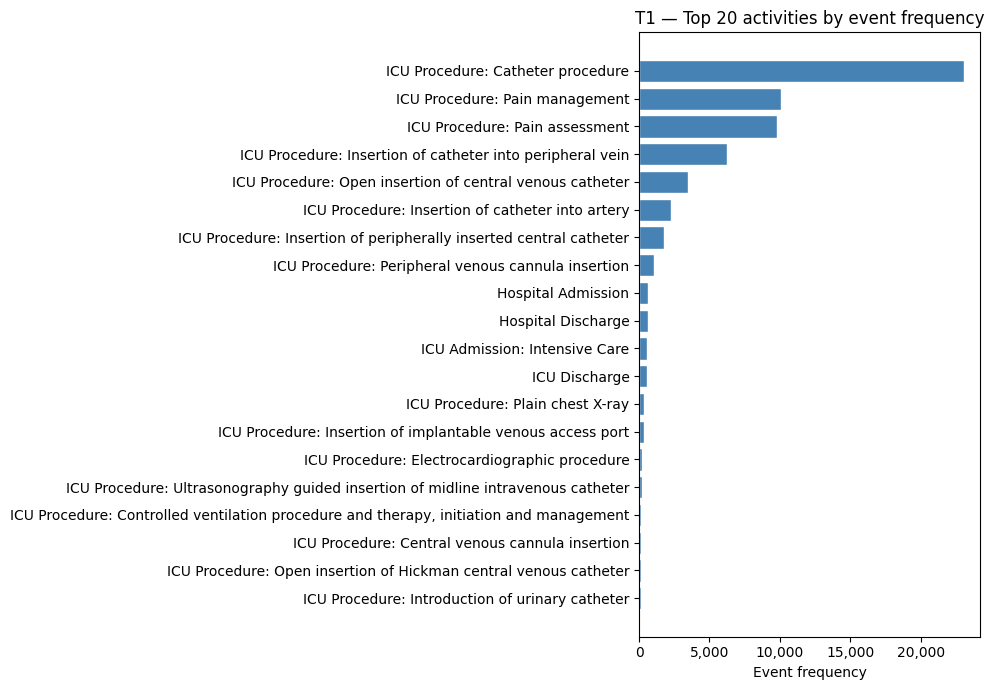

In [49]:
el_t1 = LOGS['t1']
n_cases_t1  = len(el_t1)
n_events_t1 = sum(len(t) for t in el_t1)
print(f'T1 — Cases: {n_cases_t1:,}  |  Events: {n_events_t1:,}')

# Activity frequency
_ = show_activity_freq(el_t1, n=20,
    title='T1 — Top 20 activities by event frequency')

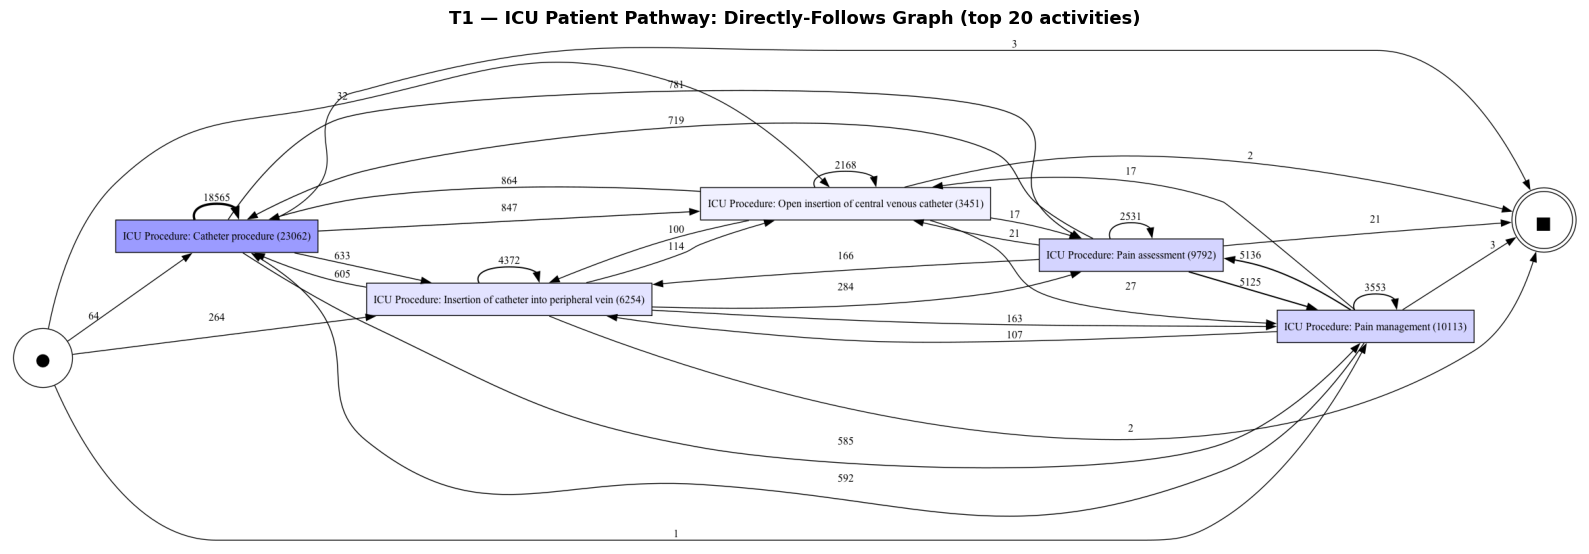

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t1_dfg_titled.png


In [50]:
# ── T1: Directly-Follows Graph (top 20 activities) ─────────────────────────
# ICU Procedures carry concept names; show top-20 to keep the graph readable.
# For the paper figure, we use max_activities=8 to show only the 5 core
# activity categories + most frequent ICU procedures.
plot_dfg(
    el_t1,
    title='T1 — ICU Patient Pathway: Directly-Follows Graph (top 20 activities)',
    fname='t1_dfg.png',
    max_activities=5,
)

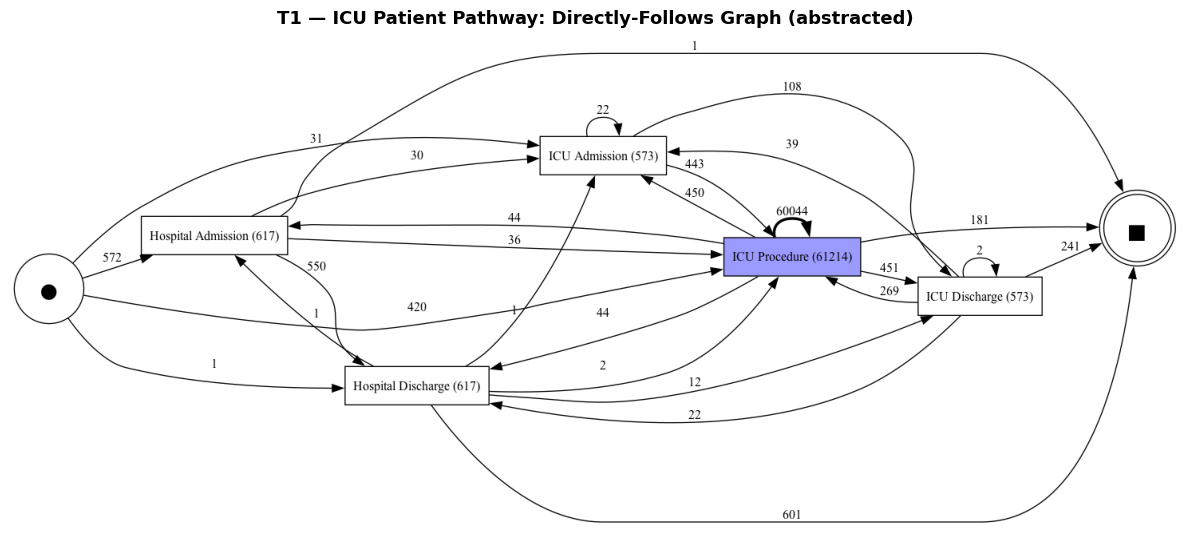

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t1_dfg_abstract_titled.png


In [51]:
# ── T1: Abstracted DFG (5 core activity categories) — paper-ready figure ──
# Collapse 'ICU Admission: Intensive Care' → 'ICU Admission',
# 'ICU Procedure: Ventilation' → 'ICU Procedure', etc.
el_t1_abs = abstract_log(el_t1)

plot_dfg(
    el_t1_abs,
    title='T1 — ICU Patient Pathway: Directly-Follows Graph (abstracted)',
    fname='t1_dfg_abstract.png',
    max_activities=10,
    figsize=(12, 6),
)

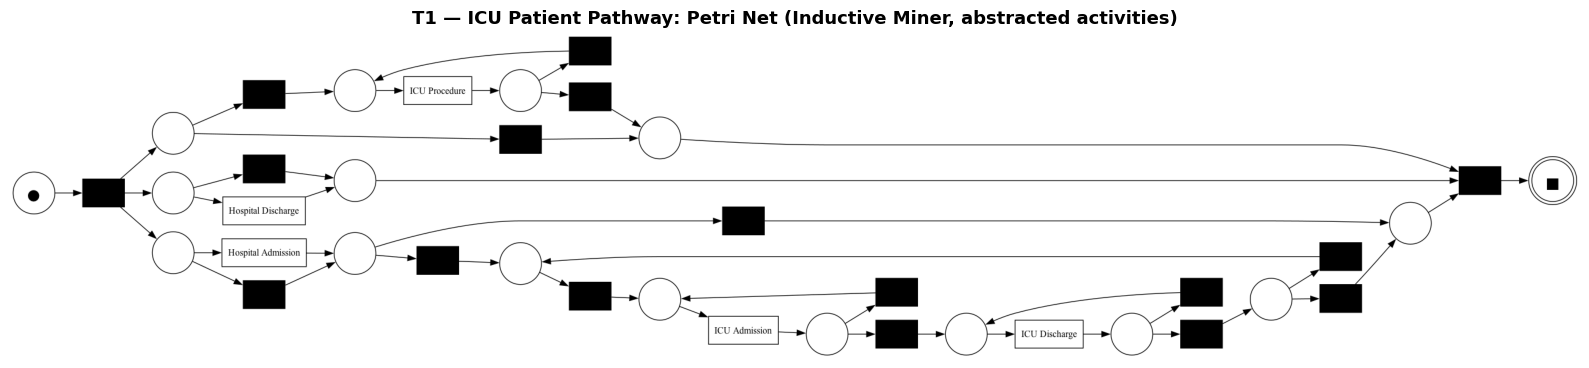

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t1_petri_net_titled.png


In [52]:
# ── T1: Inductive Miner — Petri net ───────────────────────────────────────
# Mine on the abstracted log for a clean, block-structured model.
# This is the process model figure for §5 of the paper.
plot_petri(
    el_t1_abs,
    title='T1 — ICU Patient Pathway: Petri Net (Inductive Miner, abstracted activities)',
    fname='t1_petri_net.png',
)

In [53]:
# ── T1: Top trace variants ─────────────────────────────────────────────────
_ = show_top_variants(
    el_t1_abs, n=10,
    title='T1 — ICU Patient Pathway',
)

**T1 — ICU Patient Pathway** — top 10 variants (1,024 cases)

Rank,Count,Coverage,Activities,Trace
1,550,53.7%,2,Hospital Admission → Hospital Discharge
2,8,0.8%,2,ICU Admission → ICU Discharge
3,3,0.3%,20,ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Admission …
4,3,0.3%,17,ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure …
5,2,0.2%,14,ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Admission …
6,2,0.2%,9,ICU Admission → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure …
7,2,0.2%,33,ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure …
8,2,0.2%,15,ICU Admission → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure …
9,2,0.2%,11,ICU Admission → ICU Discharge → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure …
10,2,0.2%,46,ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure → ICU Procedure …


---
## 4 · T2 — Medication Administration

Tracks drug exposure events per hospital visit: when each drug was started and
ended.  Activity labels carry the OMOP concept name of the drug
(e.g., `'Drug Started: Aspirin 81 MG'`).  Because MIMIC-IV contains hundreds
of distinct drug concepts, the **abstracted** view collapses all exposures to
two activity types (`Drug Started`, `Drug Ended`) for a clean process model,
while the **detailed** view shows the top-15 most administered drugs.

T2 — Cases: 3,528  |  Events: 399,846


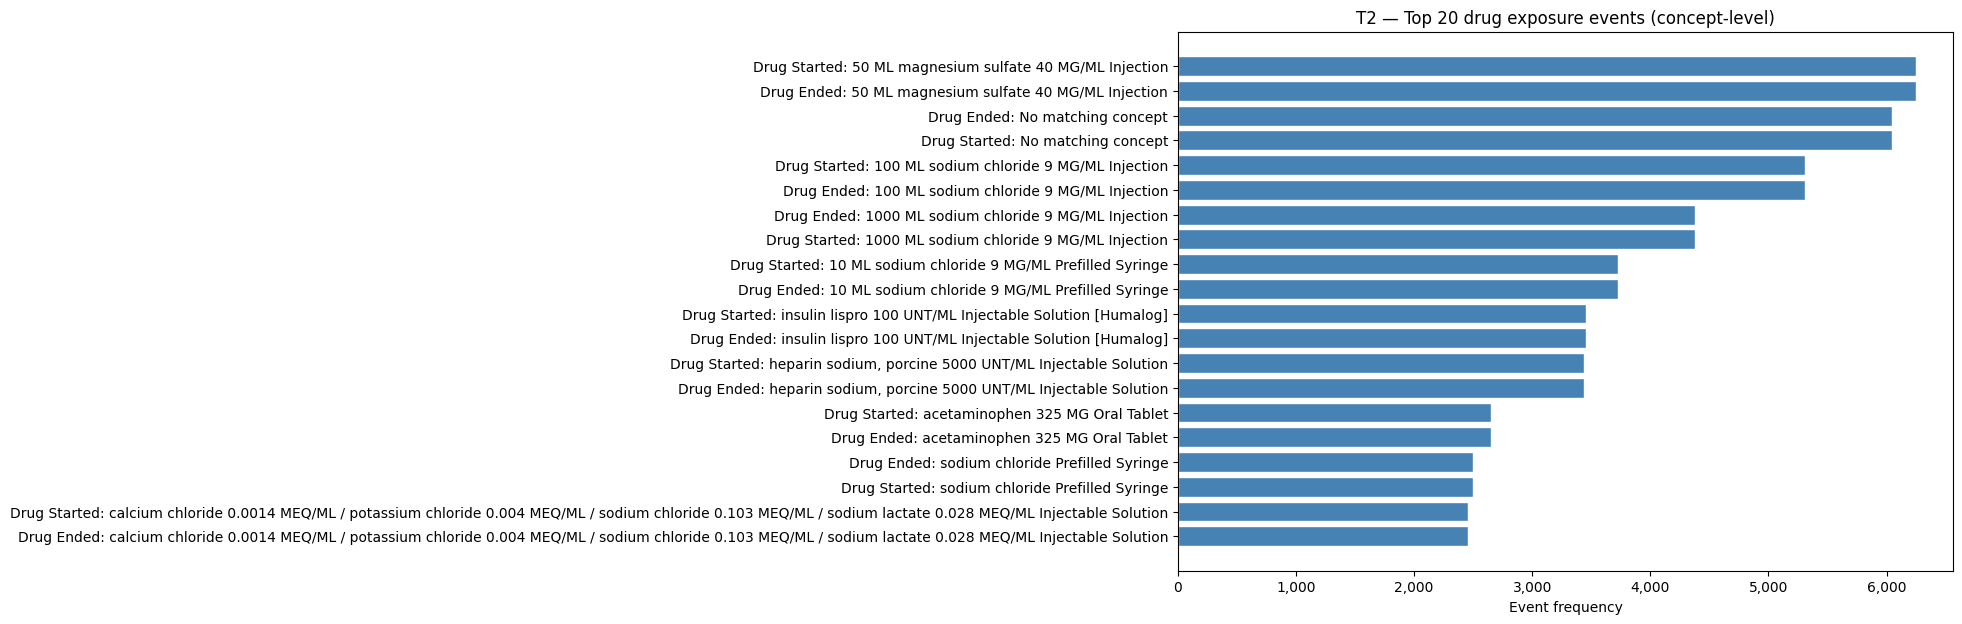

In [54]:
el_t2 = LOGS['t2']
print(f'T2 — Cases: {len(el_t2):,}  |  Events: {sum(len(t) for t in el_t2):,}')

# Raw activity frequency (top 20 drugs)
_ = show_activity_freq(el_t2, n=20,
    title='T2 — Top 20 drug exposure events (concept-level)')

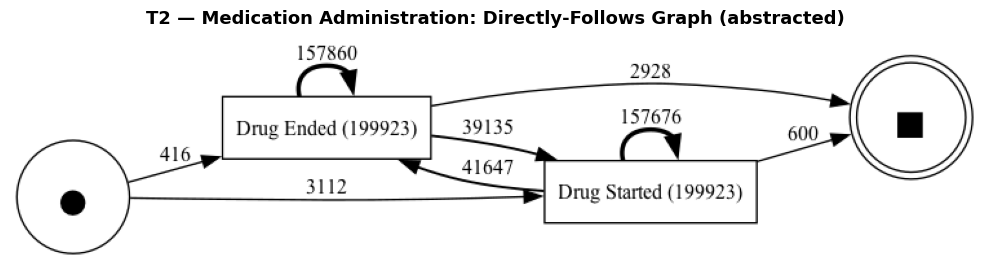

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t2_dfg_abstract_titled.png


In [55]:
# ── T2: Abstracted DFG (Drug Started / Drug Ended only) ───────────────────
el_t2_abs = abstract_log(el_t2)

plot_dfg(
    el_t2_abs,
    title='T2 — Medication Administration: Directly-Follows Graph (abstracted)',
    fname='t2_dfg_abstract.png',
    max_activities=10,
    figsize=(10, 5),
)

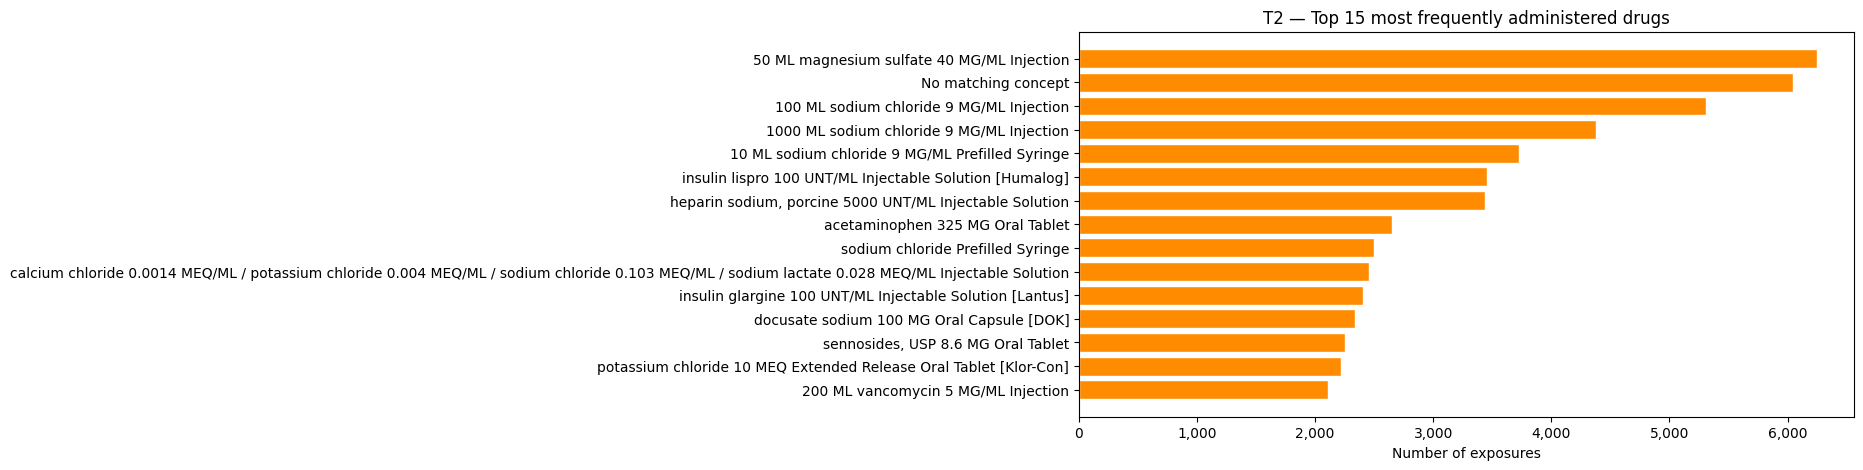

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t2_top_drugs.png


In [56]:
# ── T2: Top 15 drugs by exposure count ────────────────────────────────────
all_drugs = [
    ev['concept:name'].replace('Drug Started: ', '')
    for trace in el_t2
    for ev in trace
    if ev['concept:name'].startswith('Drug Started: ')
]
drug_counts = Counter(all_drugs)
top_drugs   = drug_counts.most_common(15)

fig, ax = plt.subplots(figsize=(10, 5))
labels  = [t[0] for t in top_drugs]
vals    = [t[1] for t in top_drugs]
ax.barh(labels[::-1], vals[::-1], color='darkorange', edgecolor='white')
ax.set_xlabel('Number of exposures')
ax.set_title('T2 — Top 15 most frequently administered drugs', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 't2_top_drugs.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved → {fig_path}')

---
## 5 · T3 — Sepsis Treatment Trajectory

Tracks sepsis patients through diagnosis, laboratory testing, drug
administration, and clinical observations.  The event log is restricted to the
350 sepsis patients in the sample (identified via 129 SNOMED concept codes).
With thousands of unique lab-test concept names, abstraction is essential for
a readable process model.

In [57]:
el_t3 = LOGS['t3']
print(f'T3 — Cases: {len(el_t3):,}  |  Events: {sum(len(t) for t in el_t3):,}')

# Category-level breakdown
cat_counts = Counter(
    ev['concept:name'].split(': ')[0]
    for trace in el_t3
    for ev in trace
)
print('\nActivity category breakdown:')
for cat, cnt in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f'  {cat:<35} {cnt:>10,}')

T3 — Cases: 500  |  Events: 1,316,115

Activity category breakdown:
  Lab Result                           1,179,556
  Observation                             78,675
  Drug Started                            57,136
  Sepsis Diagnosed                           748


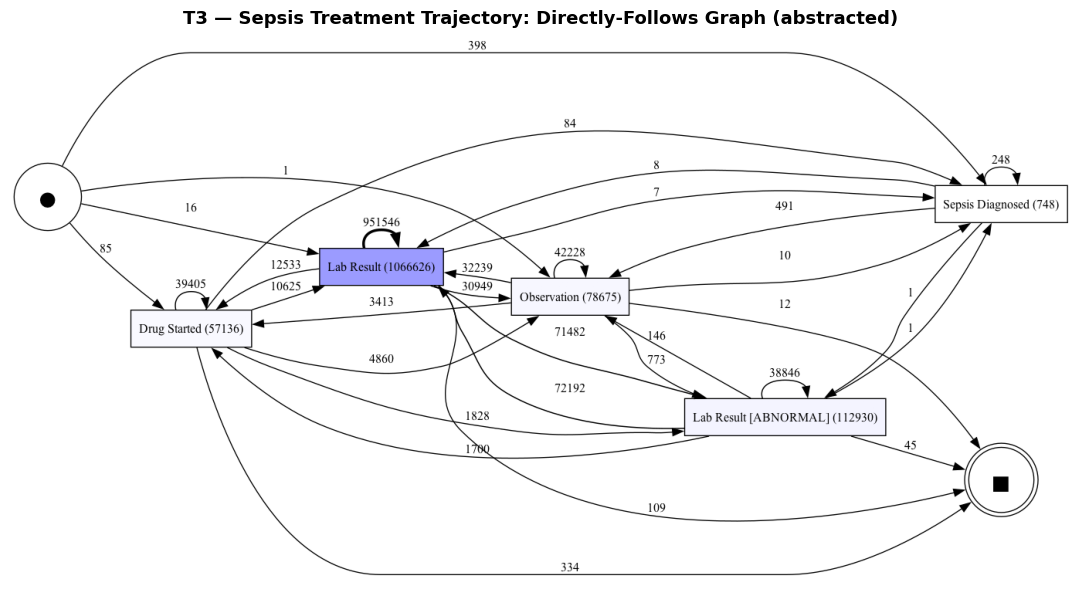

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t3_dfg_abstract_titled.png


In [58]:
# ── T3: Abstracted DFG ────────────────────────────────────────────────────
el_t3_abs = abstract_log(el_t3)

plot_dfg(
    el_t3_abs,
    title='T3 — Sepsis Treatment Trajectory: Directly-Follows Graph (abstracted)',
    fname='t3_dfg_abstract.png',
    max_activities=10,
    figsize=(12, 6),
)

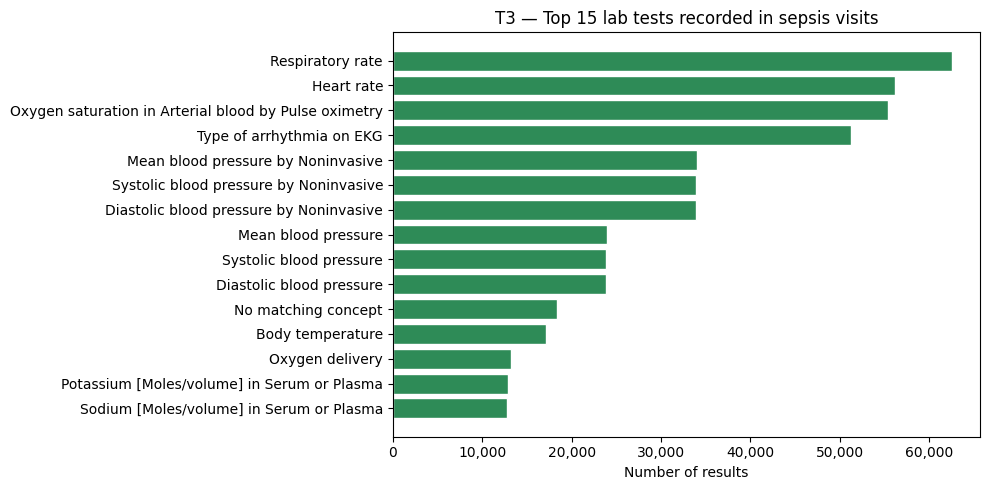

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t3_top_labs.png


In [59]:
# ── T3: Top 15 lab tests in sepsis visits ─────────────────────────────────
lab_results = [
    ev['concept:name']
    for trace in el_t3
    for ev in trace
    if ev['concept:name'].startswith('Lab Result: ')
]
# Strip '[ABNORMAL]' suffix for grouping
lab_names = [
    r.replace(' [ABNORMAL]', '').replace('Lab Result: ', '')
    for r in lab_results
]
top_labs = Counter(lab_names).most_common(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [t[0] for t in top_labs][::-1],
    [t[1] for t in top_labs][::-1],
    color='seagreen', edgecolor='white',
)
ax.set_xlabel('Number of results')
ax.set_title('T3 — Top 15 lab tests recorded in sepsis visits', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 't3_top_labs.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved → {fig_path}')

In [60]:
# ── T3: Top variants (abstracted) ─────────────────────────────────────────
_ = show_top_variants(
    el_t3_abs, n=10,
    title='T3 — Sepsis Treatment Trajectory',
)

**T3 — Sepsis Treatment Trajectory** — top 10 variants (500 cases)

Rank,Count,Coverage,Activities,Trace
1,1,0.2%,251,Sepsis Diagnosed → Sepsis Diagnosed → Observation → Observation → Lab Result → Lab Result …
2,1,0.2%,1772,Sepsis Diagnosed → Observation → Observation → Observation → Observation → Observation …
3,1,0.2%,1769,Sepsis Diagnosed → Observation → Observation → Observation → Observation → Observation …
4,1,0.2%,2204,Sepsis Diagnosed → Sepsis Diagnosed → Observation → Observation → Observation → Lab Result …
5,1,0.2%,4385,Drug Started → Drug Started → Drug Started → Drug Started → Drug Started → Sepsis Diagnosed …
6,1,0.2%,8358,Sepsis Diagnosed → Sepsis Diagnosed → Observation → Observation → Observation → Observation …
7,1,0.2%,738,Drug Started → Drug Started → Drug Started → Sepsis Diagnosed → Sepsis Diagnosed → Observation …
8,1,0.2%,2048,Sepsis Diagnosed → Observation → Observation → Observation → Observation → Observation …
9,1,0.2%,169,Drug Started → Drug Started → Drug Started → Sepsis Diagnosed → Sepsis Diagnosed → Observation …
10,1,0.2%,639,Sepsis Diagnosed → Observation → Observation → Observation → Observation → Observation …


---
## 6 · T4 — Lab-Order-to-Result Cycle

Tracks the laboratory workflow: specimen collection (linked to a hospital visit
via `person_id` + temporal window), followed by result recording and abnormal
result flagging.  The measurement table drives most of the volume
(>2.9 M rows for 888 patients); the XES log is restricted to 500 cases.

In [61]:
el_t4 = LOGS['t4']
print(f'T4 — Cases: {len(el_t4):,}  |  Events: {sum(len(t) for t in el_t4):,}')

cat_counts_t4 = Counter(
    abstract_activity(ev['concept:name'])
    for trace in el_t4
    for ev in trace
)
print('\nAbstract activity breakdown:')
for cat, cnt in sorted(cat_counts_t4.items(), key=lambda x: -x[1]):
    print(f'  {cat:<35} {cnt:>10,}')

T4 — Cases: 500  |  Events: 295,735

Abstract activity breakdown:
  Lab Result                             251,462
  Abnormal Result                         43,005
  Specimen Collected                       1,268


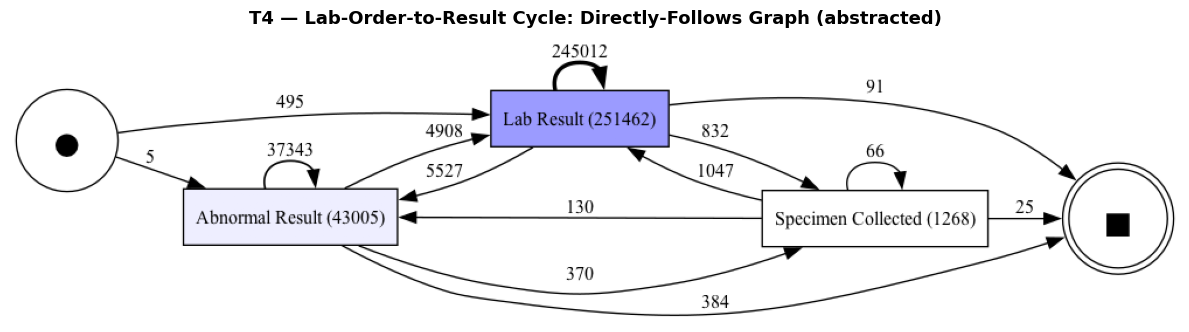

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t4_dfg_abstract_titled.png


In [62]:
# ── T4: DFG (abstracted) ──────────────────────────────────────────────────
el_t4_abs = abstract_log(el_t4)

plot_dfg(
    el_t4_abs,
    title='T4 — Lab-Order-to-Result Cycle: Directly-Follows Graph (abstracted)',
    fname='t4_dfg_abstract.png',
    max_activities=10,
    figsize=(12, 5),
)

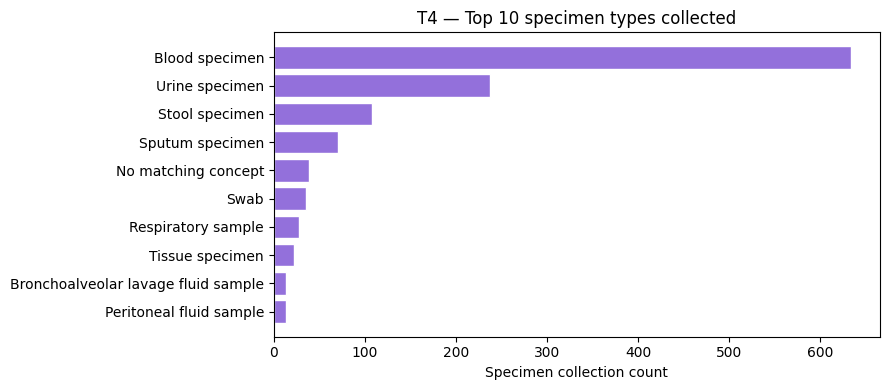

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t4_top_specimens.png


In [63]:
# ── T4: Top 15 specimen types ─────────────────────────────────────────────
specimens = [
    ev['concept:name'].replace('Specimen Collected: ', '')
    for trace in el_t4
    for ev in trace
    if ev['concept:name'].startswith('Specimen Collected: ')
]
top_spec = Counter(specimens).most_common(10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    [t[0] for t in top_spec][::-1],
    [t[1] for t in top_spec][::-1],
    color='mediumpurple', edgecolor='white',
)
ax.set_xlabel('Specimen collection count')
ax.set_title('T4 — Top 10 specimen types collected', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 't4_top_specimens.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved → {fig_path}')

---
## 7 · T5 — Emergency Department Flow

Tracks patients from ED arrival through sub-stays, diagnoses, procedures, and
departure.  With five well-defined activity categories this is the cleanest
task for Inductive Miner — the resulting Petri net is compact and immediately
clinically interpretable.

T5 — Cases: 526  |  Events: 77,320


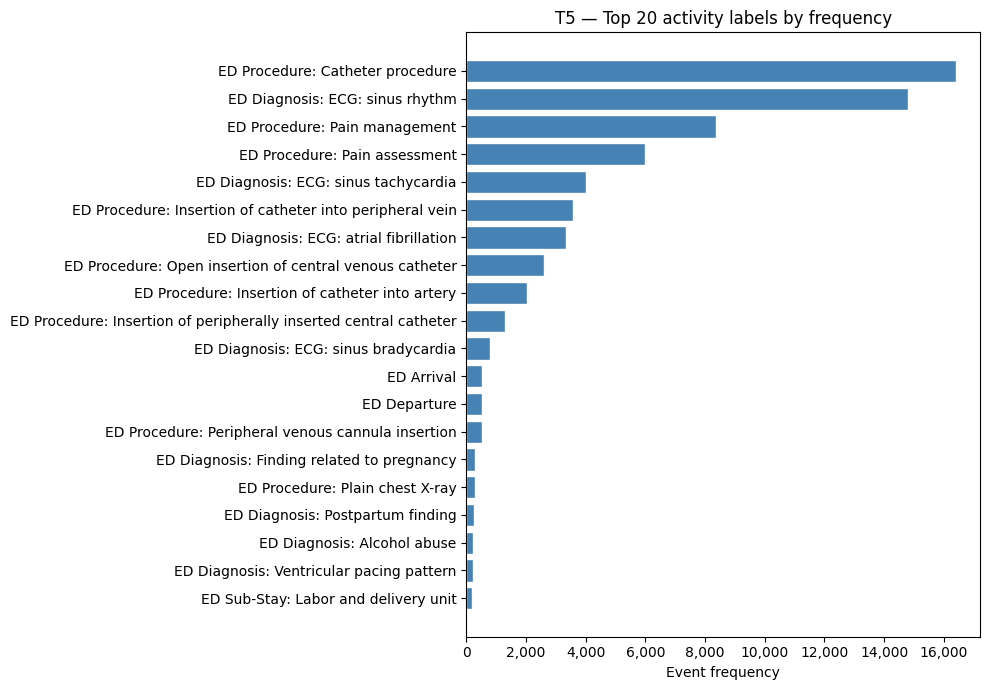

In [64]:
el_t5 = LOGS['t5']
print(f'T5 — Cases: {len(el_t5):,}  |  Events: {sum(len(t) for t in el_t5):,}')

_ = show_activity_freq(el_t5, n=20,
    title='T5 — Top 20 activity labels by frequency')

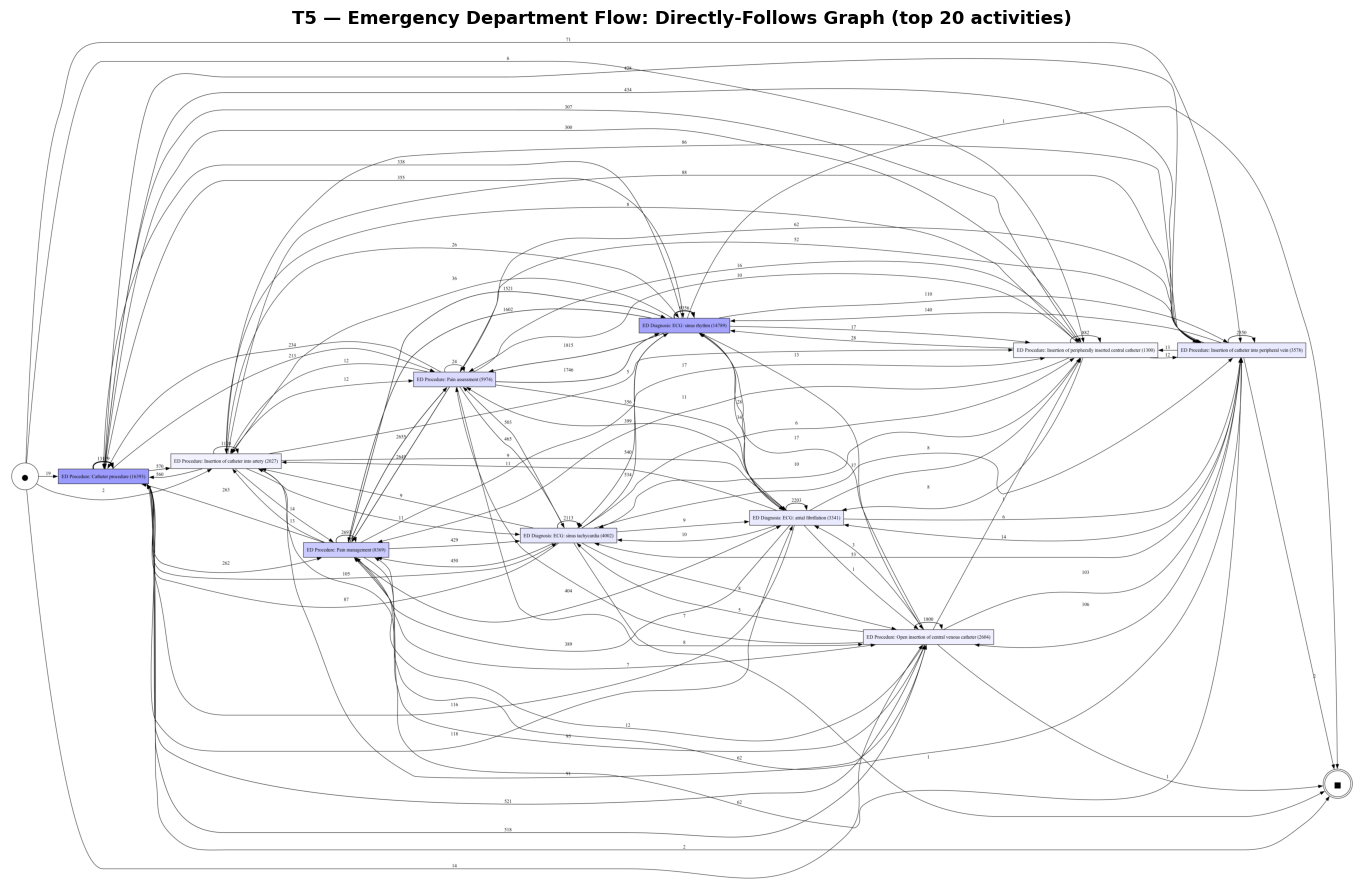

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t5_dfg_titled.png


In [66]:
# ── T5: DFG (concept-level, top 20) ───────────────────────────────────────
plot_dfg(
    el_t5,
    title='T5 — Emergency Department Flow: Directly-Follows Graph (top 20 activities)',
    fname='t5_dfg.png',
    max_activities=10,
)

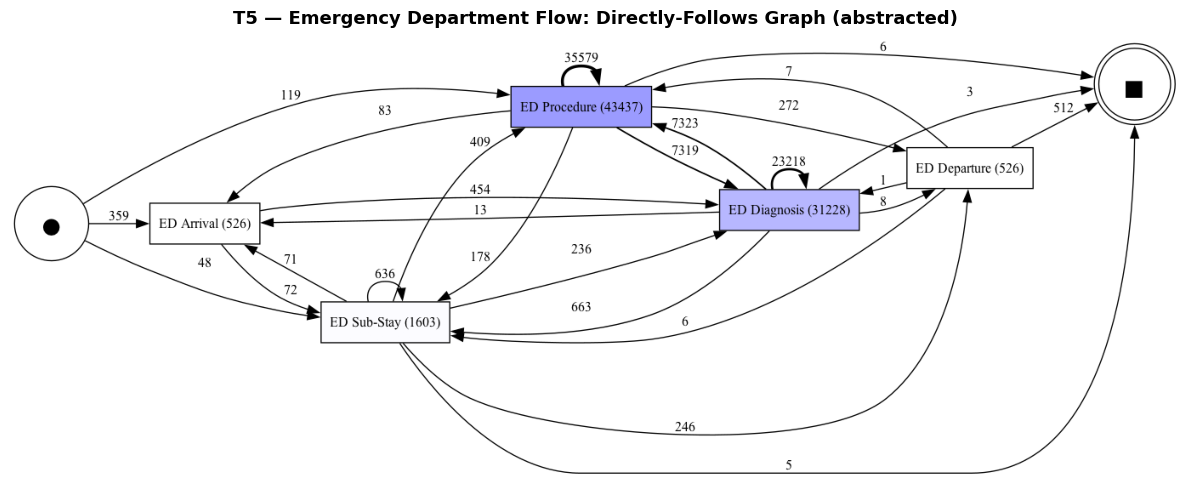

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t5_dfg_abstract_titled.png


In [67]:
# ── T5: Abstracted DFG (5 core categories) ────────────────────────────────
el_t5_abs = abstract_log(el_t5)

plot_dfg(
    el_t5_abs,
    title='T5 — Emergency Department Flow: Directly-Follows Graph (abstracted)',
    fname='t5_dfg_abstract.png',
    max_activities=10,
    figsize=(12, 6),
)

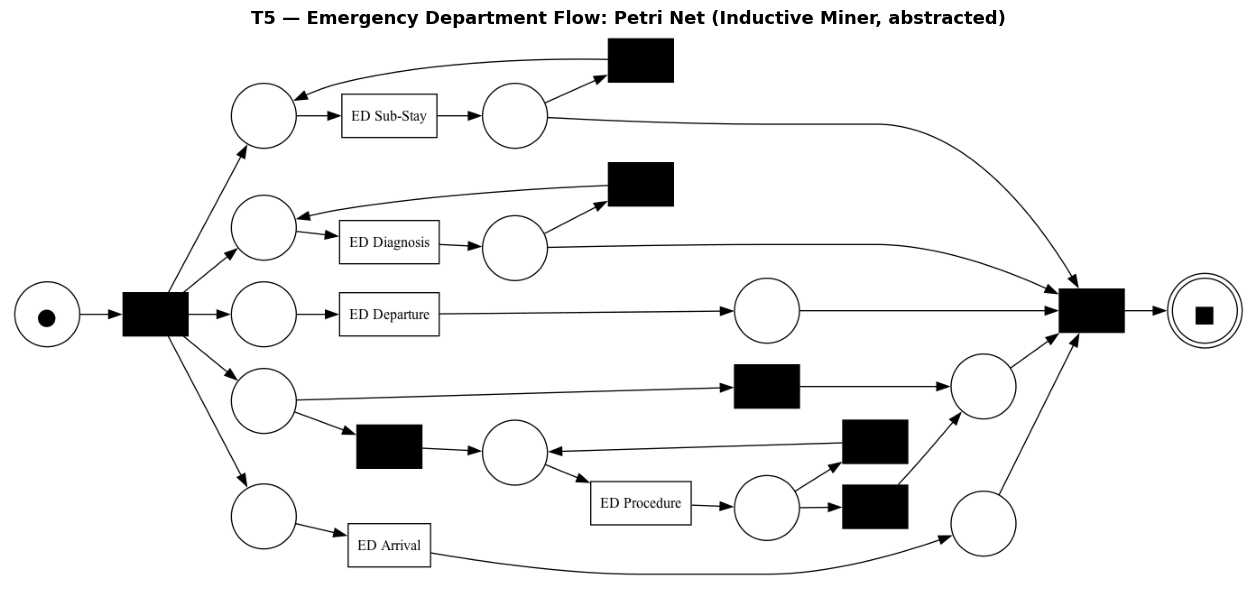

  Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/t5_petri_net_titled.png


In [68]:
# ── T5: Inductive Miner — Petri net (abstracted) ──────────────────────────
plot_petri(
    el_t5_abs,
    title='T5 — Emergency Department Flow: Petri Net (Inductive Miner, abstracted)',
    fname='t5_petri_net.png',
)

In [69]:
# ── T5: Top trace variants ─────────────────────────────────────────────────
_ = show_top_variants(
    el_t5_abs, n=10,
    title='T5 — Emergency Department Flow',
)

**T5 — Emergency Department Flow** — top 10 variants (526 cases)

Rank,Count,Coverage,Activities,Trace
1,5,1.0%,14,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis …
2,5,1.0%,15,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis …
3,5,1.0%,10,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis …
4,5,1.0%,10,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis …
5,5,1.0%,11,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis …
6,5,1.0%,11,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis …
7,4,0.8%,7,ED Arrival → ED Diagnosis → ED Diagnosis → ED Sub-Stay → ED Sub-Stay → ED Procedure …
8,4,0.8%,9,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Sub-Stay …
9,4,0.8%,17,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis …
10,4,0.8%,12,ED Arrival → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis → ED Diagnosis …


---
## 8 · Cross-Task Comparison

In [72]:
# ── Complete summary table ─────────────────────────────────────────────────
abs_logs = {
    't1': el_t1_abs,
    't2': abstract_log(LOGS['t2']),
    't3': el_t3_abs,
    't4': el_t4_abs,
    't5': el_t5_abs,
}

rows = []
for tid, el_raw in LOGS.items():
    el_a = abs_logs[tid]

    n_cases      = len(el_raw)
    n_events     = sum(len(t) for t in el_raw)
    n_act_raw    = len({ev['concept:name'] for t in el_raw for ev in t})
    n_act_abs    = len({ev['concept:name'] for t in el_a  for ev in t})
    avg_trace    = round(n_events / n_cases, 1) if n_cases else 0

    variants     = pm4py.get_variants_as_tuples(el_a)
    if isinstance(variants, dict):
        if all(isinstance(v, int) for v in variants.values()):
            variant_counts = variants
        else:
            variant_counts = {k: len(v) for k, v in variants.items()}
    else:
        variant_counts = Counter(variants)

    n_variants   = len(variant_counts)
    top1_count   = max(variant_counts.values()) if variant_counts else 0
    top1_cov     = top1_count / n_cases * 100 if n_cases else 0

    rows.append(dict(
        Task                     = tid.upper(),
        Process                  = TASK_LABELS[tid].split(' — ')[1],
        Cases                    = f'{n_cases:,}',
        Events                   = f'{n_events:,}',
        Activities_raw           = n_act_raw,
        Activities_abstracted    = n_act_abs,
        Avg_events_per_case      = avg_trace,
        Variants                 = f'{n_variants:,}',
        Top1_variant_coverage    = f'{top1_cov:.1f}%',
    ))

df_cross = pd.DataFrame(rows)
display(
    df_cross.style
    .set_caption('Table 2 — Cross-task event log comparison (MIMIC-IV OMOP CDM, 888-patient sample)')
    .hide(axis='index')
)

Task,Process,Cases,Events,Activities_raw,Activities_abstracted,Avg_events_per_case,Variants,Top1_variant_coverage
T1,ICU Patient Pathway,"1,024","63,594",295,5,62.100000,453,53.7%
T2,Medication Administration,"3,528","399,846",3918,2,113.300000,"3,233",0.8%
T3,Sepsis Treatment Trajectory,500,"1,316,115",2365,5,2632.200000,500,0.2%
T4,Lab-Order-to-Result Cycle,500,"295,735",758,3,591.500000,487,0.8%
T5,Emergency Department Flow,526,"77,320",1839,5,147.000000,409,1.0%


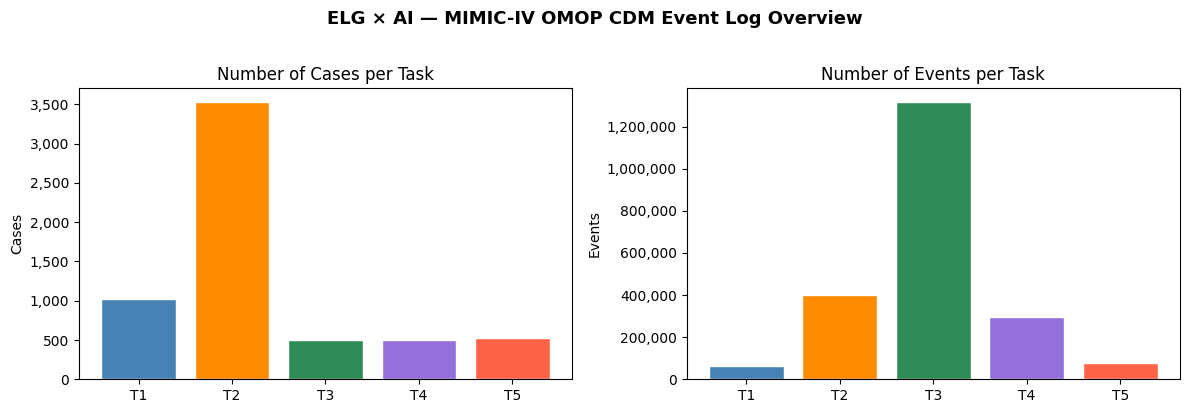

Saved → /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures/overview_cases_events.png


In [73]:
# ── Case / event count bar chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

task_ids  = [r['Task'] for r in rows]
cases     = [int(r['Cases'].replace(',',''))  for r in rows]
events    = [int(r['Events'].replace(',','')) for r in rows]
colors    = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'tomato']

axes[0].bar(task_ids, cases,  color=colors, edgecolor='white')
axes[0].set_title('Number of Cases per Task', fontsize=12)
axes[0].set_ylabel('Cases')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(task_ids, events, color=colors, edgecolor='white')
axes[1].set_title('Number of Events per Task', fontsize=12)
axes[1].set_ylabel('Events')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('ELG × AI — MIMIC-IV OMOP CDM Event Log Overview', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
overview_path = os.path.join(FIGURES_DIR, 'overview_cases_events.png')
plt.savefig(overview_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {overview_path}')

In [74]:
# ── List all saved figures ─────────────────────────────────────────────────
print('\nFigures saved to', FIGURES_DIR)
for f in sorted(os.listdir(FIGURES_DIR)):
    fpath = os.path.join(FIGURES_DIR, f)
    size  = os.path.getsize(fpath) / 1024
    print(f'  {f:<45}  {size:6.1f} KB')


Figures saved to /Users/saimir.bala/Nextcloud/Research/ELG with AI/experiment/figures
  overview_cases_events.png                        50.0 KB
  t1_dfg.png                                      227.7 KB
  t1_dfg_abstract.png                             132.5 KB
  t1_dfg_abstract_titled.png                      189.7 KB
  t1_dfg_titled.png                               264.3 KB
  t1_petri_net.png                                109.2 KB
  t1_petri_net_titled.png                         111.5 KB
  t2_dfg_abstract.png                              29.8 KB
  t2_dfg_abstract_titled.png                       95.1 KB
  t2_top_drugs.png                                126.9 KB
  t3_dfg_abstract.png                             160.7 KB
  t3_dfg_abstract_titled.png                      220.2 KB
  t3_top_labs.png                                  81.9 KB
  t4_dfg_abstract.png                              51.8 KB
  t4_dfg_abstract_titled.png                      141.1 KB
  t4_top_specimens.png      

---
## 9 · Notes for the Paper (§5 Demonstration)

The figures produced by this notebook that are directly suitable for inclusion
in the BPM 2026 paper are:

| Figure file | Section | Caption suggestion |
|---|---|---|
| `t1_dfg_abstract_titled.png` | §5.2 | *DFG of the ICU Patient Pathway event log (T1, abstracted activities, 888-patient sample)* |
| `t1_petri_net_titled.png`    | §5.3 | *Petri net discovered by the Inductive Miner on the T1 event log* |
| `t5_dfg_abstract_titled.png` | §5   | *DFG of the Emergency Department Flow (T5)* |
| `t5_petri_net_titled.png`    | §5   | *Petri net for T5 (Inductive Miner)* |
| `overview_cases_events.png`  | §6.1 | *Cases and events per clinical process task* |

### Key observation — activity label abstraction

The ground-truth SQL uses OMOP `concept_name` lookups, producing fine-grained
labels such as `'ICU Procedure: Arterial catheterization'`.  The LLM-generated
SQL typically uses hard-coded string literals (`'ICU Stay'`, `'Hospital
Admission'`), resulting in near-zero activity-label overlap (M3b = 0.17%,
M4a = 0.17%) even when case coverage is high (M3a = 78.7%).

The **abstracted DFGs** show that once labels are collapsed to category level
the structural agreement between LLM-generated and ground-truth logs is much
higher — supporting the paper's recommendation of a post-processing
normalisation step.